In [10]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns

# ============================================
# 1. СРЕДА (лабиринт)
# ============================================
env = gym.make("FrozenLake-v1", render_mode="ansi", is_slippery=False, map_name="4x4")
n_states = env.observation_space.n
n_actions = env.action_space.n

In [17]:
# ============================================
# 2. Q-таблица
# ============================================
Q = np.zeros((n_states, n_actions))

alpha = 0.1
gamma = 0.95
epsilon_final = 0.5

In [18]:
# ============================================
# 3. ОБУЧЕНИЕ
# ============================================
episodes = 2000

states = []

for ep in range(episodes):
    state, _ = env.reset()
    epsilon = epsilon_final * (ep/episodes)
    done = False
    steps = 0
    cnt = 0
    while not done:
        # epsilon-greedy
        if np.random.rand() < epsilon_final:
            cnt+=1
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        # Q-learning update
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )
        state = next_state
        states.append(state)
        steps+=1
        print(cnt/steps)

0.0
0.0
0.0
0.25
0.2
0.16666666666666666
0.14285714285714285
0.25
0.0
0.5
0.6666666666666666
0.5
0.6
0.6666666666666666
1.0
0.5
0.6666666666666666
0.75
0.6
0.6666666666666666
0.5714285714285714
0.5
0.4444444444444444
0.5
0.5454545454545454
0.5
0.46153846153846156
0.5
0.5333333333333333
0.5625
0.5882352941176471
0.6111111111111112
0.5789473684210527
0.55
0.5714285714285714
0.5909090909090909
0.5652173913043478
0.5416666666666666
0.56
0.5769230769230769
0.5555555555555556
0.5357142857142857
0.5172413793103449
0.5333333333333333
0.5483870967741935
0.53125
0.5151515151515151
0.5294117647058824
0.5428571428571428
0.5277777777777778
0.5405405405405406
0.5263157894736842
0.5128205128205128
0.5
0.4878048780487805
0.5
0.5116279069767442
0.5227272727272727
0.5333333333333333
0.5434782608695652
0.5531914893617021
0.5625
0.5714285714285714
0.56
0.5490196078431373
0.5576923076923077
0.5660377358490566
0.5555555555555556
0.5454545454545454
0.5535714285714286
0.543859649122807
0.5344827586206896
0.52

<Axes: >

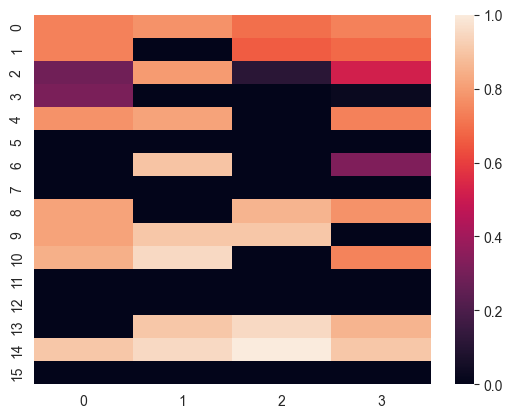

In [19]:
sns.heatmap(Q)

In [9]:
sns.heatmap((Q[:,0].reshape(8,8)))

ValueError: cannot reshape array of size 16 into shape (8,8)

<Axes: >

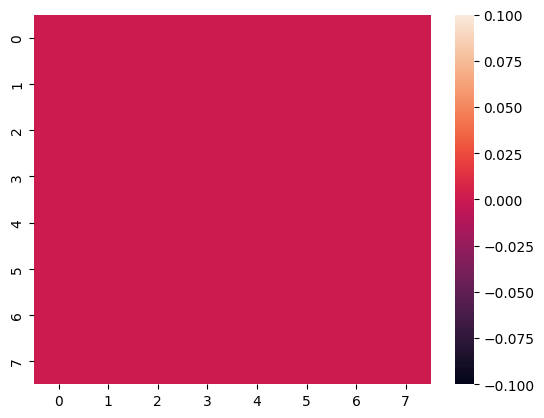

In [42]:
sns.heatmap((Q[:,1].reshape(8,8)))

<Axes: >

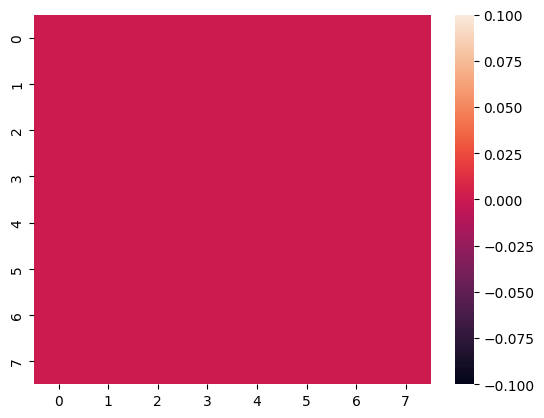

In [43]:
sns.heatmap((Q[:,2].reshape(8,8)))

<Axes: >

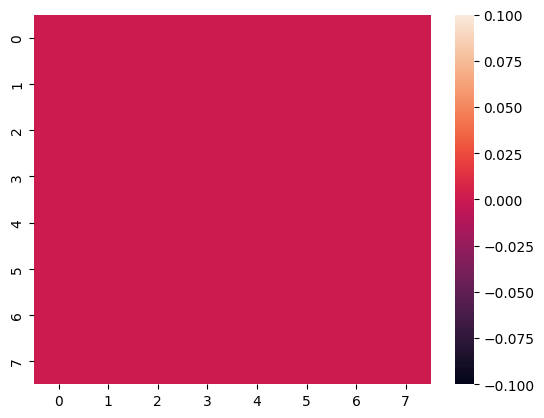

In [45]:
sns.heatmap((Q[:,3].reshape(8,8)))

In [ ]:
# ============================================
# 4. ВИЗУАЛИЗАЦИЯ ТРАЕКТОРИИ
# ============================================

def render_policy(Q):
    state, _ = env.reset()
    done = False

    grid_size = int(np.sqrt(n_states))
    trajectory = []

    while not done:
        trajectory.append(state)

        action = np.argmax(Q[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    trajectory.append(state)
    return trajectory


def plot_trajectory(trajectory):
    grid_size = int(np.sqrt(n_states))
    grid = np.zeros((grid_size, grid_size))

    fig, ax = plt.subplots()
    ax.imshow(grid)

    for i, s in enumerate(trajectory):
        x = s // grid_size
        y = s % grid_size

        ax.text(y, x, str(i), ha='center', va='center', color='red')

    ax.set_title("Agent trajectory")
    plt.show()


trajectory = render_policy(Q)
plot_trajectory(trajectory)

In [ ]:
# ============================================
# 5. АНИМАЦИЯ АГЕНТА
# ============================================

state, _ = env.reset()
done = False

print("Agent running:\n")

while not done:
    print(env.render())
    time.sleep(0.5)

    action = np.argmax(Q[state])
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

print(env.render())
print("Finished!")